# **1. Import Libraries**

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")


# **2. LOAD DATASET**

In [66]:
file_path = '/content/drive/MyDrive/credit_card_default.csv'

df = pd.read_csv(file_path)
print("Dataset Shape:", df.shape)


 Dataset loaded successfully!
Dataset Shape: (30000, 25)


# **3. BASIC DATASET INFORMATION**

In [87]:
print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate Rows:")
print(df.duplicated().sum())


First 5 Rows:


,Unnamed: 0,limit_bal,sex,education,marriage,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,...,bill_statement_jun,bill_statement_may,bill_statement_apr,previous_payment_sep,previous_payment_aug,previous_payment_jul,previous_payment_jun,previous_payment_may,previous_payment_apr,default_payment_next_month
0,0,20000,Female,University,Married,24.0,Payment delayed 2 months,Payment delayed 2 months,Payed duly,Payed duly,...,0,0,0,0,689,0,0,0,0,1
1,1,120000,Female,University,Single,26.0,Payed duly,Payment delayed 2 months,Unknown,Unknown,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,2,90000,Female,University,Single,34.0,Unknown,Unknown,Unknown,Unknown,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,3,50000,Female,University,Married,37.0,Unknown,Unknown,Unknown,Unknown,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,4,50000,Male,University,Married,57.0,Payed duly,Unknown,Payed duly,Unknown,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



Column Names:
['Unnamed: 0', 'limit_bal', 'sex', 'education', 'marriage', 'age', 'payment_status_sep', 'payment_status_aug', 'payment_status_jul', 'payment_status_jun', 'payment_status_may', 'payment_status_apr', 'bill_statement_sep', 'bill_statement_aug', 'bill_statement_jul', 'bill_statement_jun', 'bill_statement_may', 'bill_statement_apr', 'previous_payment_sep', 'previous_payment_aug', 'previous_payment_jul', 'previous_payment_jun', 'previous_payment_may', 'previous_payment_apr', 'default_payment_next_month']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  30000 non-null  int64  
 1   limit_bal                   30000 non-null  int64  
 2   sex                         30000 non-null  object 
 3   education                   30000 non-null  object 
 4   ma

,Missing Values
Unnamed: 0,0
limit_bal,0
sex,0
education,0
marriage,0
age,0
payment_status_sep,0
payment_status_aug,0
payment_status_jul,0
payment_status_jun,0



Duplicate Rows:
0


# **4. FIND TARGET COLUMN**

In [68]:
possible_targets = [
    col for col in df.columns
    if any(word in col.lower() for word in
           ['default', 'target', 'class', 'label'])
]

if len(possible_targets) == 0:
    raise ValueError(
        "Target column automatically identify nahi ho saka. "
        "Apne dataset ka target column manually set karo."
    )

target = possible_targets[0]

print("\n Target Column:")
print(target)

print("\nTarget Distribution:")
print(df[target].value_counts())

print("\nTarget Percentage:")
print(
    (df[target].value_counts(normalize=True) * 100)
    .round(2)
)



 Target Column:
default_payment_next_month

Target Distribution:
default_payment_next_month
0    23364
1     6636
Name: count, dtype: int64

Target Percentage:
default_payment_next_month
0    77.88
1    22.12
Name: proportion, dtype: float64


# **5. TARGET VISUALIZATION**

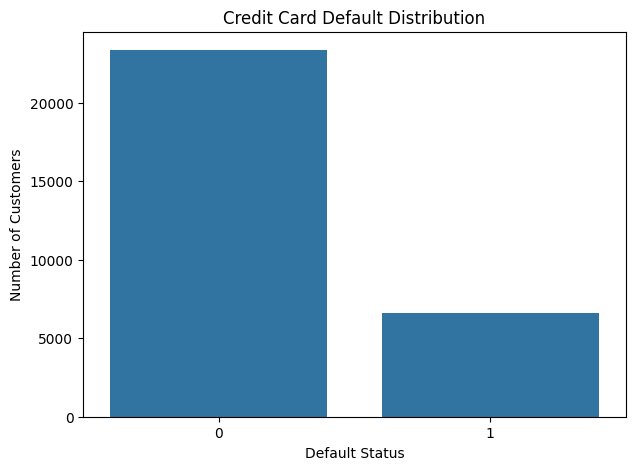

In [69]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x=target)

plt.title("Credit Card Default Distribution")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")

plt.show()

# **6. REMOVE DUPLICATES**

In [70]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("\nDuplicate rows removed:", before - after)
print("New dataset shape:", df.shape)


Duplicate rows removed: 0
New dataset shape: (30000, 25)


# **7. HANDLE MISSING VALUES**

In [71]:
print("\nMissing values before cleaning:")
print(df.isnull().sum().sum())

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())


categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns

for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum().sum())


Missing values before cleaning:
600

Missing values after cleaning:
0


# **8. REMOVE ID-LIKE COLUMNS**

In [72]:
id_columns = []

for col in df.columns:

    col_lower = col.lower()

    if (
        col_lower == 'id'
        or col_lower.endswith('_id')
        or col_lower.endswith('id')
        or 'customer_id' in col_lower
        or 'client_id' in col_lower
    ):
        if col != target:
            id_columns.append(col)

if id_columns:

    print("\nID columns removed:")
    print(id_columns)

    df = df.drop(columns=id_columns)

else:

    print("\nNo ID columns detected.")


No ID columns detected.


# **9. SPLIT FEATURES AND TARGET**

In [73]:

X = df.drop(columns=[target])
y = df[target]

print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (30000, 24)
Target shape: (30000,)


# **10. ENCODE TARGET IF NECESSARY**

In [74]:
if y.dtype == 'object' or str(y.dtype) == 'category':

    label_encoder = LabelEncoder()

    y = label_encoder.fit_transform(y)

    print("\nTarget labels encoded:")
    print(label_encoder.classes_)

else:

    y = y.values

# **11. IDENTIFY NUMERIC AND CATEGORICAL FEATURES**

In [75]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("\nNumeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


Numeric Features:
['Unnamed: 0', 'limit_bal', 'age', 'bill_statement_sep', 'bill_statement_aug', 'bill_statement_jul', 'bill_statement_jun', 'bill_statement_may', 'bill_statement_apr', 'previous_payment_sep', 'previous_payment_aug', 'previous_payment_jul', 'previous_payment_jun', 'previous_payment_may', 'previous_payment_apr']

Categorical Features:
['sex', 'education', 'marriage', 'payment_status_sep', 'payment_status_aug', 'payment_status_jul', 'payment_status_jun', 'payment_status_may', 'payment_status_apr']


# **12. PREPROCESSING**

In [76]:
try:

    encoder = OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    )

except TypeError:

    encoder = OneHotEncoder(
        handle_unknown='ignore',
        sparse=False
    )

preprocessor = ColumnTransformer(
    transformers=[

        (
            'numeric',
            StandardScaler(),
            numeric_features
        ),

        (
            'categorical',
            encoder,
            categorical_features
        )

    ],

    remainder='drop'

)


# **13. TRAIN / TEST SPLIT**

In [77]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 24000
Testing samples: 6000


# **14. DEFINE MACHINE LEARNING MODELS**

In [78]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ),

    "SVM":
        SVC(
            kernel='rbf'
        ),

    "Naive Bayes":
        GaussianNB()

}

# **15. TRAIN ALL MODELS**

In [79]:
results = []

trained_models = {}

predictions = {}

for name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ('preprocessing', preprocessor),
            ('model', model)
        ]
    )
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    results.append({

        'Model': name,

        'Accuracy': accuracy,

        'Precision': precision,

        'Recall': recall,

        'F1-Score': f1

    })

    trained_models[name] = pipeline

    predictions[name] = y_pred

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

Accuracy : 0.8178
Precision: 0.8000
Recall   : 0.8178
F1-Score : 0.7958
Accuracy : 0.7963
Precision: 0.7724
Recall   : 0.7963
F1-Score : 0.7757
Accuracy : 0.7192
Precision: 0.7281
Recall   : 0.7192
F1-Score : 0.7234
Accuracy : 0.8155
Precision: 0.7968
Recall   : 0.8155
F1-Score : 0.7943
Accuracy : 0.8173
Precision: 0.8001
Recall   : 0.8173
F1-Score : 0.7905
Accuracy : 0.7902
Precision: 0.7610
Recall   : 0.7902
F1-Score : 0.7298


# **16. MODEL COMPARISON TABLE**

In [80]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='F1-Score',
    ascending=False
).reset_index(drop=True)
display(
    results_df.style.format({
        'Accuracy': '{:.2%}',
        'Precision': '{:.2%}',
        'Recall': '{:.2%}',
        'F1-Score': '{:.2%}'
    })
)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,81.78%,80.00%,81.78%,79.58%
1,Random Forest,81.55%,79.68%,81.55%,79.43%
2,SVM,81.73%,80.01%,81.73%,79.05%
3,KNN,79.63%,77.24%,79.63%,77.57%
4,Naive Bayes,79.02%,76.10%,79.02%,72.98%
5,Decision Tree,71.92%,72.81%,71.92%,72.34%


# **17. MODEL COMPARISON GRAPH**

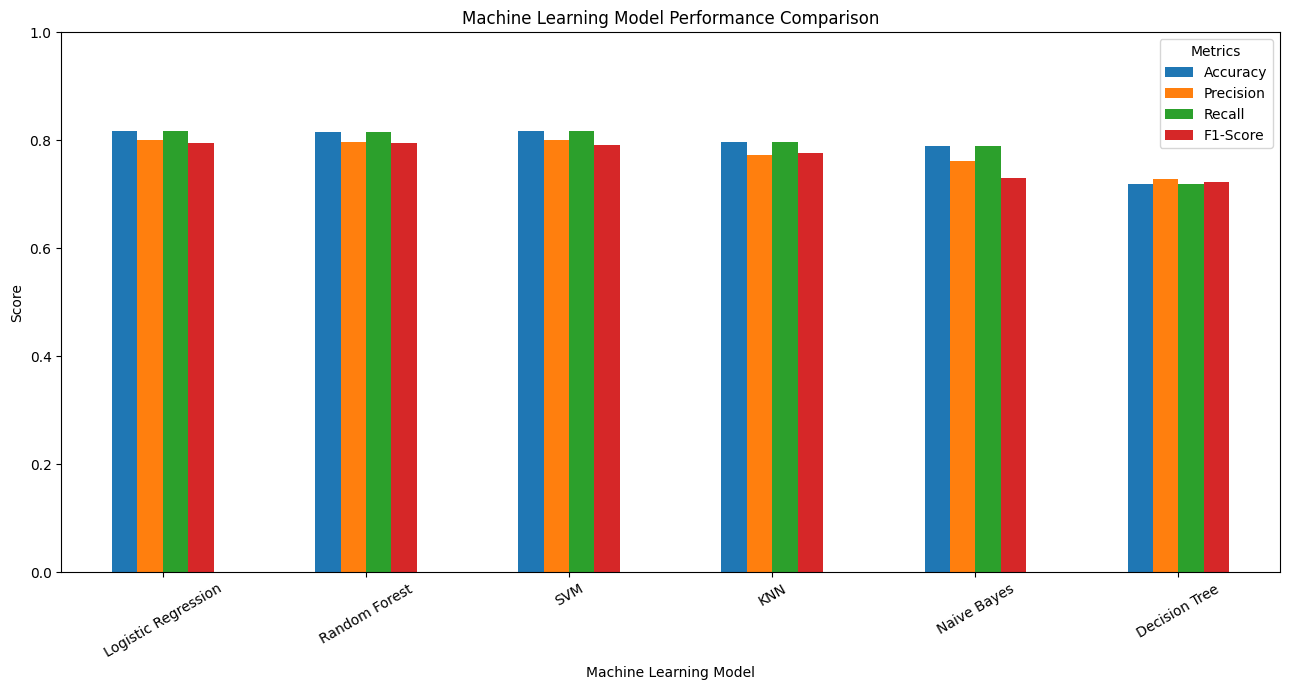

In [81]:
metrics = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score'
]

results_plot = results_df.set_index('Model')[metrics]

results_plot.plot(
    kind='bar',
    figsize=(13, 7)
)

plt.title(
    'Machine Learning Model Performance Comparison'
)

plt.xlabel('Machine Learning Model')

plt.ylabel('Score')

plt.ylim(0, 1)

plt.xticks(rotation=30)

plt.legend(
    title='Metrics'
)

plt.tight_layout()

plt.show()


# **18. CONFUSION MATRICES**

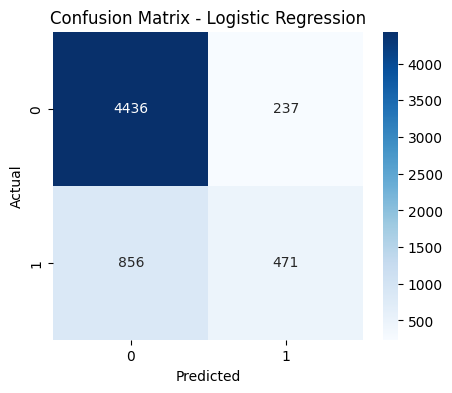

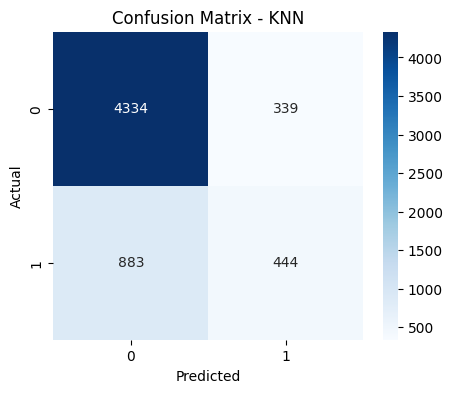

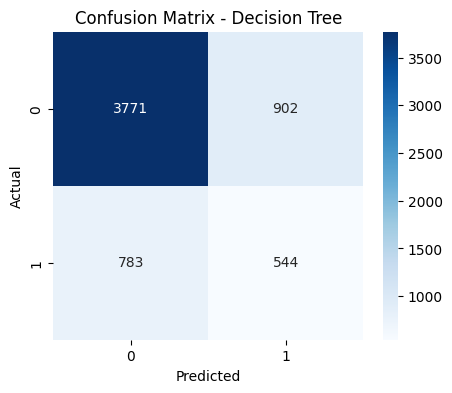

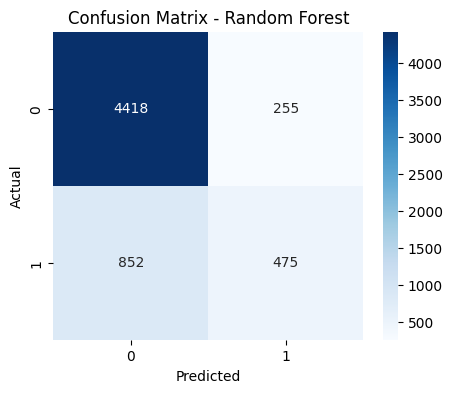

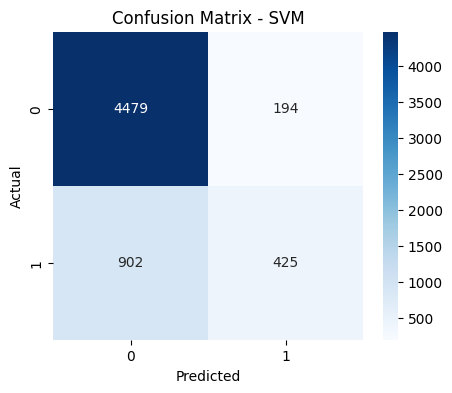

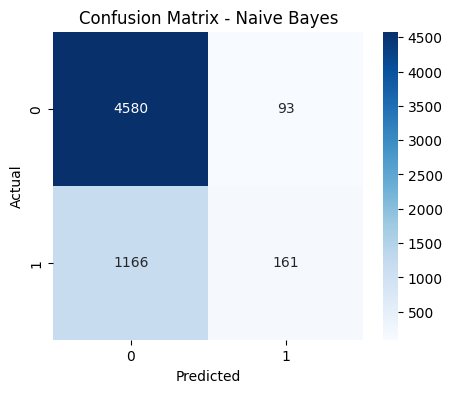

In [82]:
for name in models.keys():

    y_pred = predictions[name]

    cm = confusion_matrix(
        y_test,
        y_pred
    )
    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(
        f'Confusion Matrix - {name}'
    )
    plt.xlabel('Predicted')

    plt.ylabel('Actual')

    plt.show()

# **19. CLASSIFICATION REPORTS**

In [83]:
for name in models.keys():
    print(
        classification_report(
            y_test,
            predictions[name],
            zero_division=0
        )
    )

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000

              precision    recall  f1-score   support

           0       0.83      0.93      0.88      4673
           1       0.57      0.33      0.42      1327

    accuracy                           0.80      6000
   macro avg       0.70      0.63      0.65      6000
weighted avg       0.77      0.80      0.78      6000

              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4673
           1       0.38      0.41      0.39      1327

    accuracy                           0.72      6000
   macro avg       0.60      0.61      0.60      6000
weighted avg       0.73      0.72      0.72      6000

              preci

# **20. BEST MODEL**

In [84]:

best_model_name = results_df.iloc[0]['Model']

best_model = trained_models[
    best_model_name
]
print(
    f"Best Model: {best_model_name}"
)

best_row = results_df.iloc[0]

print(
    f"Accuracy : {best_row['Accuracy']:.2%}"
)

print(
    f"Precision: {best_row['Precision']:.2%}"
)

print(
    f"Recall   : {best_row['Recall']:.2%}"
)

print(
    f"F1-Score : {best_row['F1-Score']:.2%}"
)

Best Model: Logistic Regression
Accuracy : 81.78%
Precision: 80.00%
Recall   : 81.78%
F1-Score : 79.58%


# **21. SAVE RESULTS**

In [85]:
results_df.to_csv(
    '/content/creditguard_model_comparison.csv',
    index=False
)
print("\n Model comparison saved as:")
print("creditguard_model_comparison.csv")


 Model comparison saved as:
creditguard_model_comparison.csv


# **22. FINAL PROJECT SUMMARY**

In [86]:


print("\nProject: Credit Card Default Risk Prediction")
print("\nModels Applied:")
for model_name in models.keys():
    print("✔", model_name)

print("\nEvaluation Metrics:")

print("✔ Accuracy")
print("✔ Precision")
print("✔ Recall")
print("✔ F1-Score")
print("✔ Confusion Matrix")

print("\n Best Model:")
print(best_model_name)



Project: Credit Card Default Risk Prediction

Models Applied:
✔ Logistic Regression
✔ KNN
✔ Decision Tree
✔ Random Forest
✔ SVM
✔ Naive Bayes

Evaluation Metrics:
✔ Accuracy
✔ Precision
✔ Recall
✔ F1-Score
✔ Confusion Matrix

 Best Model:
Logistic Regression
